## 1. Import & Setup

In [1]:
import pandas as pd
import numpy as np
import re
from cleantext import clean
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
from transformers import XLNetTokenizer, XLNetForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset, DatasetDict
import evaluate

import matplotlib.pyplot as plt
import random

print("Done import!")

Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.


Done import!


## 2. Reading and Matching Data

In [2]:
# Reading 3 fileS CSV
train_df = pd.read_csv('./my_emotions_fined_tune/emotion-labels-train.csv')
test_df= pd.read_csv('./my_emotions_fined_tune/emotion-labels-test.csv')
val_df= pd.read_csv('./my_emotions_fined_tune/emotion-labels-test.csv')

In [3]:
train_df.head()

,text,label
0,Just had the best espresso ever!! ☕️✨ #blessed,joy
1,Finally got that promotion! Hard work pays off...,joy
2,Omg thank you so much for the gift! You're a s...,joy
3,Best. Day. Ever. period. ❤️🌈 #happy,joy
4,"Sunshine and coffee, what else do I need? ☀️☕️",joy


In [4]:
# Combine into a single table for shared processing
all_data = pd.concat([train_df, test_df, val_df], ignore_index=True)

In [5]:
all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    36 non-null     str  
 1   label   36 non-null     str  
dtypes: str(2)
memory usage: 2.6 KB


In [6]:
all_data.head(16)

,text,label
0,Just had the best espresso ever!! ☕️✨ #blessed,joy
1,Finally got that promotion! Hard work pays off...,joy
2,Omg thank you so much for the gift! You're a s...,joy
3,Best. Day. Ever. period. ❤️🌈 #happy,joy
4,"Sunshine and coffee, what else do I need? ☀️☕️",joy
5,Great weather for a walk! 🌳👟,joy
6,I've been waiting for 40 mins... where is my o...,anger
7,STOP TAGGING ME IN THESE USELESS POSTS!!! 🤬,anger
8,Why is the internet so slow today?! I hate thi...,anger
9,Who do you think you are talking to me like th...,anger


In [7]:
all_data['label'].value_counts()

label
joy        12
anger       8
sadness     8
fear        8
Name: count, dtype: int64

<Axes: xlabel='label'>

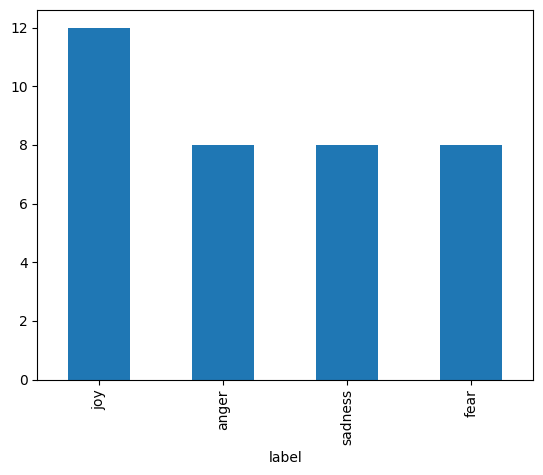

In [8]:
# plot bar chart
all_data['label'].value_counts().plot(kind="bar")

## 3. Clean up the text

In [9]:
def clean_my_text(text):
    # Remove emojis, URLs, email addresses, and phone numbers (if any).
    text = clean(text, no_emoji=True, no_urls=True, no_emails=True, no_phone_numbers=True, lang='en')

    # Remove the mention of @username (very common on Twitter)
    text = re.sub(r'@[^\s]+', '', text)
    
    # Remove multiple consecutive spaces, convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip().lower()

    return text

# Create new column
all_data['clean_text'] = all_data['text'].apply(clean_my_text)

In [10]:
all_data.head(16)

,text,label,clean_text
0,Just had the best espresso ever!! ☕️✨ #blessed,joy,just had the best espresso ever!! #blessed
1,Finally got that promotion! Hard work pays off...,joy,finally got that promotion! hard work pays off!
2,Omg thank you so much for the gift! You're a s...,joy,omg thank you so much for the gift! you're a s...
3,Best. Day. Ever. period. ❤️🌈 #happy,joy,best. day. ever. period. #happy
4,"Sunshine and coffee, what else do I need? ☀️☕️",joy,"sunshine and coffee, what else do i need?"
5,Great weather for a walk! 🌳👟,joy,great weather for a walk!
6,I've been waiting for 40 mins... where is my o...,anger,i've been waiting for 40 mins... where is my o...
7,STOP TAGGING ME IN THESE USELESS POSTS!!! 🤬,anger,stop tagging me in these useless posts!!!
8,Why is the internet so slow today?! I hate thi...,anger,why is the internet so slow today?! i hate this!
9,Who do you think you are talking to me like th...,anger,who do you think you are talking to me like th...


In [11]:
# Compare before and after (see 2 example lines)
for i in [2, 8, 16]:
    print(f'\nBefore: {all_data['text'].iloc[i]}')
    print(f'After: {all_data['clean_text'].iloc[i]}')


Before: Omg thank you so much for the gift! You're a star! 🌟💖
After: omg thank you so much for the gift! you're a star!

Before: Why is the internet so slow today?! I hate this! 🖕
After: why is the internet so slow today?! i hate this!

Before: My heart is full of gratitude today! 🙏✨
After: my heart is full of gratitude today!


## 4. Balance the number of samples in each class.

In [12]:
# View the distribution before balancing
print(f'Before balacing: {all_data['label'].value_counts()}')

Before balacing: label
joy        12
anger       8
sadness     8
fear        8
Name: count, dtype: int64


In [13]:
# Get the smallest number in the classes
min_samples = all_data['label'].value_counts().min()
print(f'Hold {min_samples} for each emotions')

Hold 8 for each emotions


In [14]:
# Create a list of sampled sub-tables
balanced_list = []

for emotion in all_data['label'].unique():
    # Extract these lines that express emotions
    subset = all_data[all_data['label'] == emotion]
    
    #Randomly select the correct min_samples row
    sampled_subset = subset.sample(n=min_samples, random_state=42)
    
    # Add to list
    balanced_list.append(sampled_subset)

# Merge all the smaller tables into balanced_data.
balanced_data = pd.concat(balanced_list).reset_index(drop=True)

# Double-check - It definitely works!
print(f'After balancing: {balanced_data['label'].value_counts().sort_index()}')

After balancing: label
anger      8
fear       8
joy        8
sadness    8
Name: count, dtype: int64


<Axes: title={'center': 'Distribution after balancing'}, xlabel='label'>

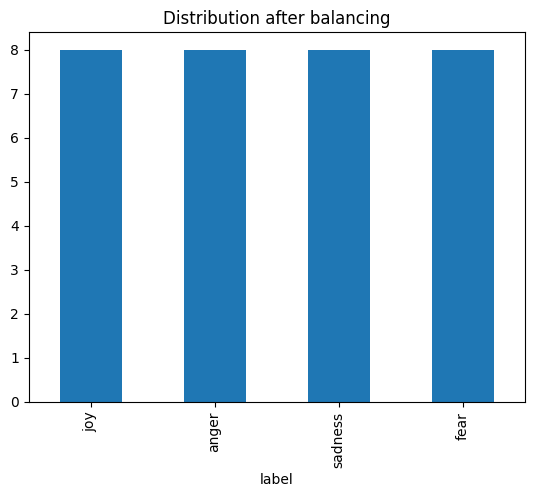

In [15]:
# Plot a chart for visual verification.
balanced_data['label'].value_counts().plot(kind='bar', title='Distribution after balancing')

## 5. Convert labels to numbers + Split train/val/test

In [16]:
# Convert label series  -> numbers (0,1,2,3, ect.)
label_encoder = LabelEncoder()
balanced_data['label_int'] = label_encoder.fit_transform(balanced_data['label'])

In [17]:
balanced_data['label_int']

0     2
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    3
17    3
18    3
19    3
20    3
21    3
22    3
23    3
24    1
25    1
26    1
27    1
28    1
29    1
30    1
31    1
Name: label_int, dtype: int64

In [18]:
# View mapping
print('Mapping: ', dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

Mapping:  {'anger': 0, 'fear': 1, 'joy': 2, 'sadness': 3}


In [19]:
# Data split: 80% for training, the rest for testing. In training, use 80% real training data + 20% validation data.
train_val, test_split = train_test_split(
    balanced_data, 
    test_size=0.2,
    stratify=balanced_data['label_int'],
    random_state=42
)

train_split, val_split = train_test_split(
    train_val,
    test_size = 0.2,
    stratify=train_val['label_int'],
    random_state = 42
)
print(f"Train: {len(train_split)} samples")
print(f"Val  : {len(val_split)} samples")
print(f"Test : {len(test_split)} samples")

Train: 20 samples
Val  : 5 samples
Test : 7 samples


## 6. Prepare a dataset for Hugging Face + Tokenize

In [20]:
tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')

def tokenize_function(examples):
    return tokenizer (
        examples['clean_text'],
        padding='max_length',
        truncation=True,
        max_length = 128
    )
    
# Create a Dataset from pandas
train_dataset = Dataset.from_pandas(train_split[['clean_text', 'label_int']].rename(columns={'label_int': 'labels'}))
test_dataset  = Dataset.from_pandas(test_split[['clean_text', 'label_int']].rename(columns={'label_int': 'labels'}))

dataset_dict = DatasetDict({
    'train': train_dataset,
    'test': test_dataset   # We're using tests as temporary validation (because the original code doesn't use val_split).
})

# Tokenize
tokenized_datasets = dataset_dict.map(
    tokenize_function, 
    batched=True
)

# Check out one sample.
print(tokenized_datasets['train'][0]['clean_text'])
print(tokenized_datasets['train'][0]['input_ids'][:30], "...")

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/7 [00:00<?, ? examples/s]

trying to hold back the tears in public.
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] ...


## 7. Fine-tune & Usage (the core)

In [21]:
# Load the model with the correct number of classes.
model = XLNetForSequenceClassification.from_pretrained(
    'xlnet-base-cased',
    num_labels=4,
    id2label={0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'},
    label2id={'anger':0, 'fear':1, 'joy':2, 'sadness':3}
)

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
# Metric
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)

In [23]:
# Training Configuration
training_args = TrainingArguments(
    output_dir="./xlnet-emotion-results",
    num_train_epochs=3,
    
    # Reduce the batch size to a safe level (4 or 8).
    per_device_train_batch_size=4, 
    per_device_eval_batch_size=4,
    
    # Use Gradient Accumulation to compensate for the reduction in batch size.
    gradient_accumulation_steps=4, 
    
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    logging_steps=10, 

    fp16=True,
)

/usr/local/python/3.12.1/lib/python3.12/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [24]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    compute_metrics=compute_metrics,
)

In [25]:
# Start training
trainer.train()

# Save the best model
trainer.save_model("./my_fine_tuned_xlnet_emotion")

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.296312,0.571429


In [26]:
# Use as a mini chatbot
from transformers import pipeline

clf = pipeline(
    "text-classification",
    model="./my_fine_tuned_xlnet_emotion",
    tokenizer=tokenizer,
    return_all_scores=True   # to see the probability for all classes
)

Device set to use cpu
/usr/local/python/3.12.1/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [28]:
# Test case
texts = [
    "i feel so happy today, finally got promoted!",
    "this is the worst day ever, everything is ruined",
    "i'm really scared about tomorrow's exam",
    "why is everyone so annoying today?!"
]

for text in texts:
    clean_t = clean_my_text(text)
    result = clf(clean_t)
    print(f"\nSentence: {text}")
    print("Prediction:", result)


Sentence: i feel so happy today, finally got promoted!
Prediction: [[{'label': 'anger', 'score': 0.18938791751861572}, {'label': 'fear', 'score': 0.15046870708465576}, {'label': 'joy', 'score': 0.3737148642539978}, {'label': 'sadness', 'score': 0.2864285111427307}]]

Sentence: this is the worst day ever, everything is ruined
Prediction: [[{'label': 'anger', 'score': 0.28131377696990967}, {'label': 'fear', 'score': 0.24120202660560608}, {'label': 'joy', 'score': 0.26080599427223206}, {'label': 'sadness', 'score': 0.2166781723499298}]]

Sentence: i'm really scared about tomorrow's exam
Prediction: [[{'label': 'anger', 'score': 0.2347358614206314}, {'label': 'fear', 'score': 0.25491365790367126}, {'label': 'joy', 'score': 0.24458380043506622}, {'label': 'sadness', 'score': 0.2657666802406311}]]

Sentence: why is everyone so annoying today?!
Prediction: [[{'label': 'anger', 'score': 0.272803395986557}, {'label': 'fear', 'score': 0.2368004471063614}, {'label': 'joy', 'score': 0.24976514279